In [1]:
import pyXLMS
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def pipeline(filename: str) -> int:
    pr = pyXLMS.parser.read(filename, engine="xiSearch/xiFDR", crosslinker="PhoX")
    csms = pr["crosslink-spectrum-matches"]
    return len(pyXLMS.transform.targets_only(csms))

In [3]:
cv1 = {
    "Cscore": pipeline("../xiFDR/CV48/Cscore_CV48_CSM_xiFDR2.3.10.csv"),
    "Partial Cscore": pipeline("../xiFDR/CV48/Partial_Cscore_CV48_CSM_xiFDR2.3.10.csv"),
    "Match Score": 0,  # pipeline("../xiFDR/CV48/Match_Score_CV48_CSM_xiFDR2.3.10.csv"),
    "UniScore": pipeline("../xiFDR/CV48/UniScore_CV486_CSM_xiFDR2.3.10.csv"),
}
cv2 = {
    "Cscore": pipeline("../xiFDR/CV486075/Cscore_CV486075_CSM_xiFDR2.3.10.csv"),
    "Partial Cscore": pipeline(
        "../xiFDR/CV486075/Partial_Cscore_CV486075_CSM_xiFDR2.3.10.csv"
    ),
    "Match Score": 0,  # pipeline("../xiFDR/CV486075/Match_Score_CV486075_CSM_xiFDR2.3.10.csv"),
    "UniScore": pipeline("../xiFDR/CV486075/UniScore_CV486075_CSM_xiFDR2.3.10.csv"),
}

Reading xiFDR CSMs...: 100%|████████████████████████████████████████████████████████████| 6/6 [00:00<00:00, 845.09it/s]


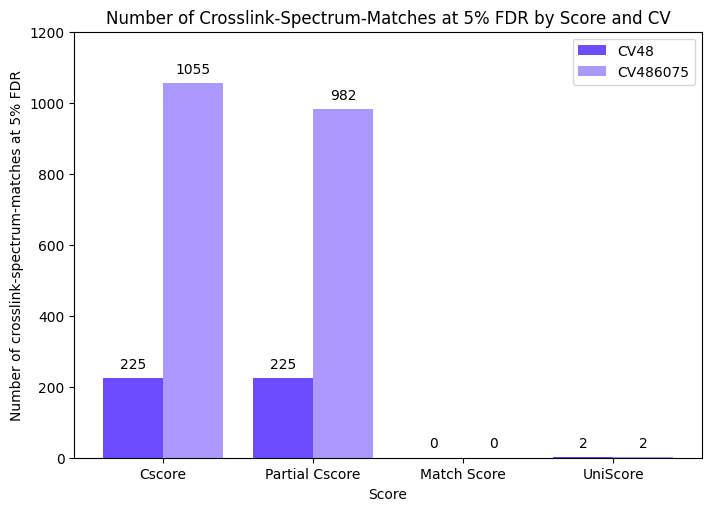

In [4]:
score_names = ("Cscore", "Partial Cscore", "Match Score", "UniScore")
scores = {
    "CV48": (
        cv1["Cscore"],
        cv1["Partial Cscore"],
        cv1["Match Score"],
        cv1["UniScore"],
    ),
    "CV486075": (
        cv2["Cscore"],
        cv2["Partial Cscore"],
        cv2["Match Score"],
        cv2["UniScore"],
    ),
}

x = np.arange(len(score_names))
width = 0.4
multiplier = 0

fig, ax = plt.subplots(layout="constrained", figsize=(7, 5))

colors = ["#6d4bff", "#ac99ff"]
for attribute, measurement in scores.items():
    offset = width * multiplier
    rects = ax.bar(
        x + offset, measurement, width, label=attribute, color=colors[multiplier % 2]
    )
    ax.bar_label(rects, padding=5, fmt="{:.0f}")
    multiplier += 1

ax.set_xlabel("Score")
ax.set_ylabel("Number of crosslink-spectrum-matches at 5% FDR")
ax.set_title("Number of Crosslink-Spectrum-Matches at 5% FDR by Score and CV")
ax.set_xticks(x + width / 2, score_names)
ax.legend(loc="upper right", ncols=1)
ax.set_ylim(0, 1200)

plt.savefig(
    "../plots/score_comparison_xiFDR.svg",
    dpi=300,
    transparent=True,
    bbox_inches="tight",
)